In [10]:
import pandas as pd
import seaborn as sea
import matplotlib.pyplot as plt
import numpy as np

# um Warnungen zu ignorieren (auf eigene Gefahr!)
import warnings
warnings.filterwarnings("ignore")

## Häufigkeiten

In [11]:
# einlesen des Datensatzes
netflix = pd.read_excel('all-weeks-countries.xlsx')

# Ansicht des Datensatzes mit .head (erste Zeilen) und .tail (letzte Zeilen)
# Dokumentation head: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.head.html#pandas.DataFrame.head
# Dokumentation tail: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.tail.html#pandas.DataFrame.tail
display(netflix.head(3))
display(netflix.tail(5))

# gesamte Anzahl an Zeilen und Spalten
print('Größe des Datensatzes: {}'.format(netflix.shape))

,country_name,country_iso2,week,category,weekly_rank,show_title,season_title,cumulative_weeks_in_top_10
0,Argentina,AR,2024-08-18,Films,1,I Can't Live Without You,NaN,1
1,Argentina,AR,2024-08-18,Films,2,The Union,NaN,1
2,Argentina,AR,2024-08-18,Films,3,Lolo and the Kid,NaN,1


,country_name,country_iso2,week,category,weekly_rank,show_title,season_title,cumulative_weeks_in_top_10
305735,Vietnam,VN,2021-07-04,TV,6,Reply 1988,Reply 1988: Season 1,1
305736,Vietnam,VN,2021-07-04,TV,7,"Nevertheless,","Nevertheless,: Limited Series",1
305737,Vietnam,VN,2021-07-04,TV,8,Too Hot to Handle,Too Hot to Handle: Season 2,1
305738,Vietnam,VN,2021-07-04,TV,9,Record of Ragnarok,Record of Ragnarok: Season 1,1
305739,Vietnam,VN,2021-07-04,TV,10,Crash Landing on You,Crash Landing on You: Limited Series,1


Größe des Datensatzes: (305740, 8)


In [12]:
# allgemeine Infos zum Datensatz
display(netflix.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 305740 entries, 0 to 305739
Data columns (total 8 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   country_name                305740 non-null  object
 1   country_iso2                305740 non-null  object
 2   week                        305740 non-null  object
 3   category                    305740 non-null  object
 4   weekly_rank                 305740 non-null  int64 
 5   show_title                  305740 non-null  object
 6   season_title                149056 non-null  object
 7   cumulative_weeks_in_top_10  305740 non-null  int64 
dtypes: int64(2), object(6)
memory usage: 18.7+ MB


None

In [13]:
# statistische Kennzahlen zum Datensatz
display(netflix.describe())

,weekly_rank,cumulative_weeks_in_top_10
count,305740.000000,305740.000000
mean,5.500000,3.429133
std,2.872286,6.338209
min,1.000000,1.000000
25%,3.000000,1.000000
50%,5.500000,2.000000
75%,8.000000,3.000000
max,10.000000,120.000000


Im folgenden sind wir an der Bestimmung von Häufigkeiten interessiert. Dazu reduzieren wir in einem ersten Schritt den Datensatz auf die Einträge der Woche vom 8. August 2024.

In [14]:
# reduzieren des Datensatzes auf 2024-08-18 in der Spalte week mittels logischer abfrage entlang des Zeilenindex
netflix_lastweek = netflix[netflix['week']=='2024-08-18']
print('neue Größe des Datensatzes: {}'.format(netflix_lastweek.shape))

# Welche Kategorien stehen zur Verfügung?
# .value_counts: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.value_counts.html#pandas.DataFrame.value_counts
display(netflix_lastweek['category'].value_counts())

neue Größe des Datensatzes: (1860, 8)


category
Films    930
TV       930
Name: count, dtype: int64

## FRAGE 

Reduziere den Datensatz weiter, so dass nur das wöchentliche Topergebnis (weekly_rank=1) aller Länder in der Kategorie Film enthalten ist. Welche Filme sind wie oft enthalten?  

In [21]:
netflix_reduced = netflix_lastweek[
    (netflix_lastweek['category'] == 'Films') &
    (netflix_lastweek['weekly_rank'] == 1)
]


In [22]:
netflix_reduced.value_counts('show_title')

show_title
The Union                             63
Kingsman: The Secret Service           8
Mission: Cross                         5
Phir Aayi Hasseen Dillruba             4
Dancing Village : The Curse Begins     2
Lolo and the Kid                       2
I Can't Live Without You               2
Ghostbusters: Frozen Empire            2
Aadujeevitham: The Goat Life           1
Double Life                            1
Minions: The Rise of Gru               1
Red Poppies                            1
Something Like Gold                    1
Name: count, dtype: int64

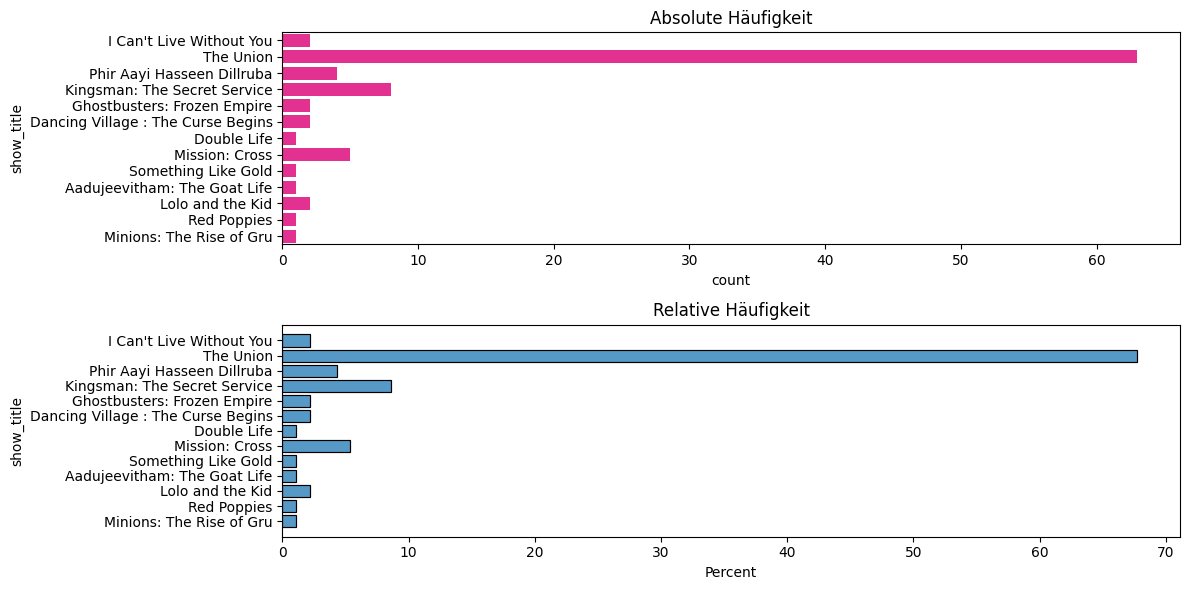

In [29]:
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(12, 6))

# oberer Plot
sea.countplot(
    data=netflix_reduced,
    y='show_title',
    ax=axs[0],
    color='deeppink'
)

# unterer Plot
sea.histplot(
    data=netflix_reduced,
    y='show_title',
    stat='percent',
    ax=axs[1],
    shrink=0.8,
    discrete=True
)

axs[0].set_title('Absolute Häufigkeit')
axs[1].set_title('Relative Häufigkeit')

plt.tight_layout()
plt.show()


### Visualisierung

Wir nehmen jetzt anstatt der Filme, die top-gerankten TV-Serien und erstellen entsprechende Häufigkeitsdiagramme.

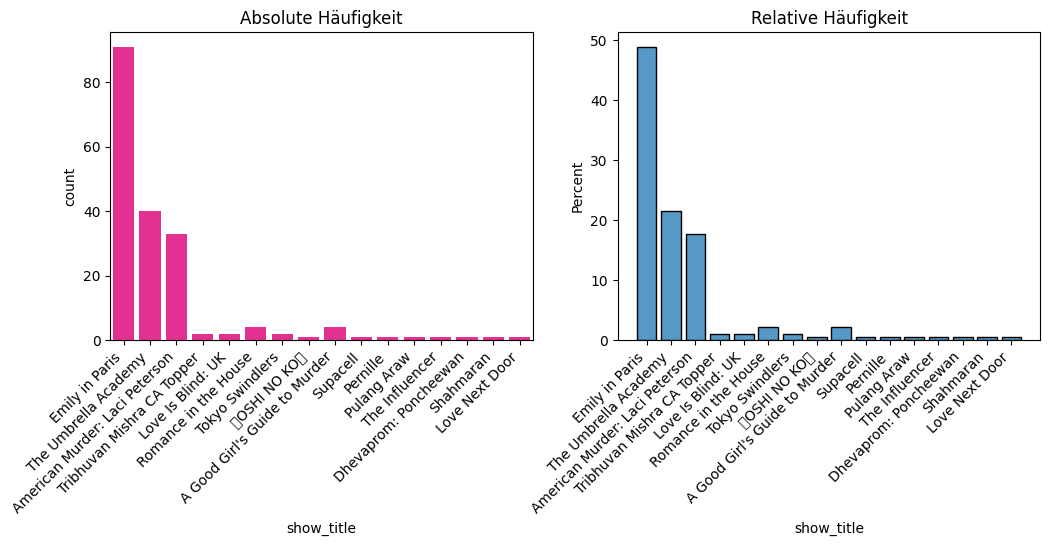

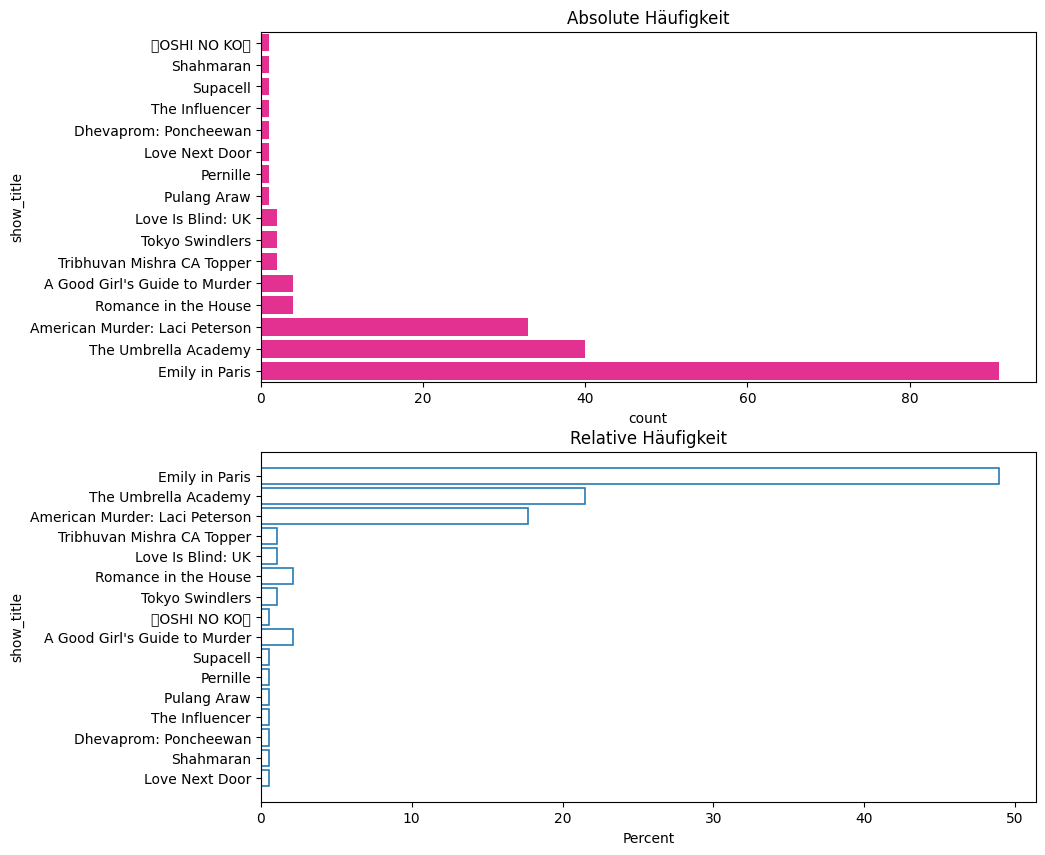

In [30]:
# tv-serien
netflix_toptv = netflix_lastweek[(netflix_lastweek['weekly_rank']<3) & (netflix_lastweek['category']=='TV')]

# Darstellung von Häufigkeitsdiagrammen mittels seaborn
fig, axs = plt.subplots(nrows=1, ncols= 2,figsize=(12,4))
sea.countplot(data=netflix_toptv, x='show_title', ax=axs[0], color='deeppink')
sea.histplot(data=netflix_toptv, x='show_title', stat='percent', ax=axs[1], shrink=0.8, discrete=True)
axs[0].set_title('Absolute Häufigkeit')
axs[1].set_title('Relative Häufigkeit')

# rotieren der x-Achsen Beschriftungen für verbesserte Lesbarkeit
for j in [0,1]:
    labels = axs[j].get_xticklabels()
    axs[j].set_xticks(labels=labels, ticks=np.arange(len(labels)), rotation=45.,\
                  horizontalalignment='right')
plt.show()

# countplot: https://seaborn.pydata.org/generated/seaborn.countplot.html
# histplot: https://seaborn.pydata.org/generated/seaborn.histplot.html

# bestimmung einer geordneten Liste der Ausprägungen
sorted_counts = netflix_toptv.value_counts('show_title')

# weitere Darstellungsformen
index = sorted_counts.sort_values().index.tolist()
fig, axs = plt.subplots(2,1,figsize=(10,10))
sea.countplot(data=netflix_toptv, y='show_title', ax=axs[0], color='deeppink', order=index)
sea.histplot(data=netflix_toptv, y='show_title', stat='percent', ax=axs[1], shrink=0.8, \
             discrete=True, fill=False)
axs[0].set_title('Absolute Häufigkeit')
axs[1].set_title('Relative Häufigkeit')

plt.show()

## Frage 

Wie sieht das relative und das absolute Häufigkeitsdiagramm der Ränge für den Film *Red Notice* über alle Länder und alle Wochen aus? Wie würde eine Darstellung einer entsprechenden kumulativen Häufigkeit der Ränge aussehen?

In [38]:
netflix_RedNotice = netflix[netflix['show_title']=='Red Notice']

display(netflix_RedNotice.head(5))
display(netflix_RedNotice.tail(5))

,country_name,country_iso2,week,category,weekly_rank,show_title,season_title,cumulative_weeks_in_top_10
2825,Argentina,AR,2021-12-05,Films,6,Red Notice,NaN,4
2842,Argentina,AR,2021-11-28,Films,3,Red Notice,NaN,3
2860,Argentina,AR,2021-11-21,Films,1,Red Notice,NaN,2
2880,Argentina,AR,2021-11-14,Films,1,Red Notice,NaN,1
6084,Australia,AU,2021-12-12,Films,5,Red Notice,NaN,5


,country_name,country_iso2,week,category,weekly_rank,show_title,season_title,cumulative_weeks_in_top_10
305262,Vietnam,VN,2021-12-12,Films,3,Red Notice,NaN,5
305280,Vietnam,VN,2021-12-05,Films,1,Red Notice,NaN,4
305300,Vietnam,VN,2021-11-28,Films,1,Red Notice,NaN,3
305320,Vietnam,VN,2021-11-21,Films,1,Red Notice,NaN,2
305340,Vietnam,VN,2021-11-14,Films,1,Red Notice,NaN,1


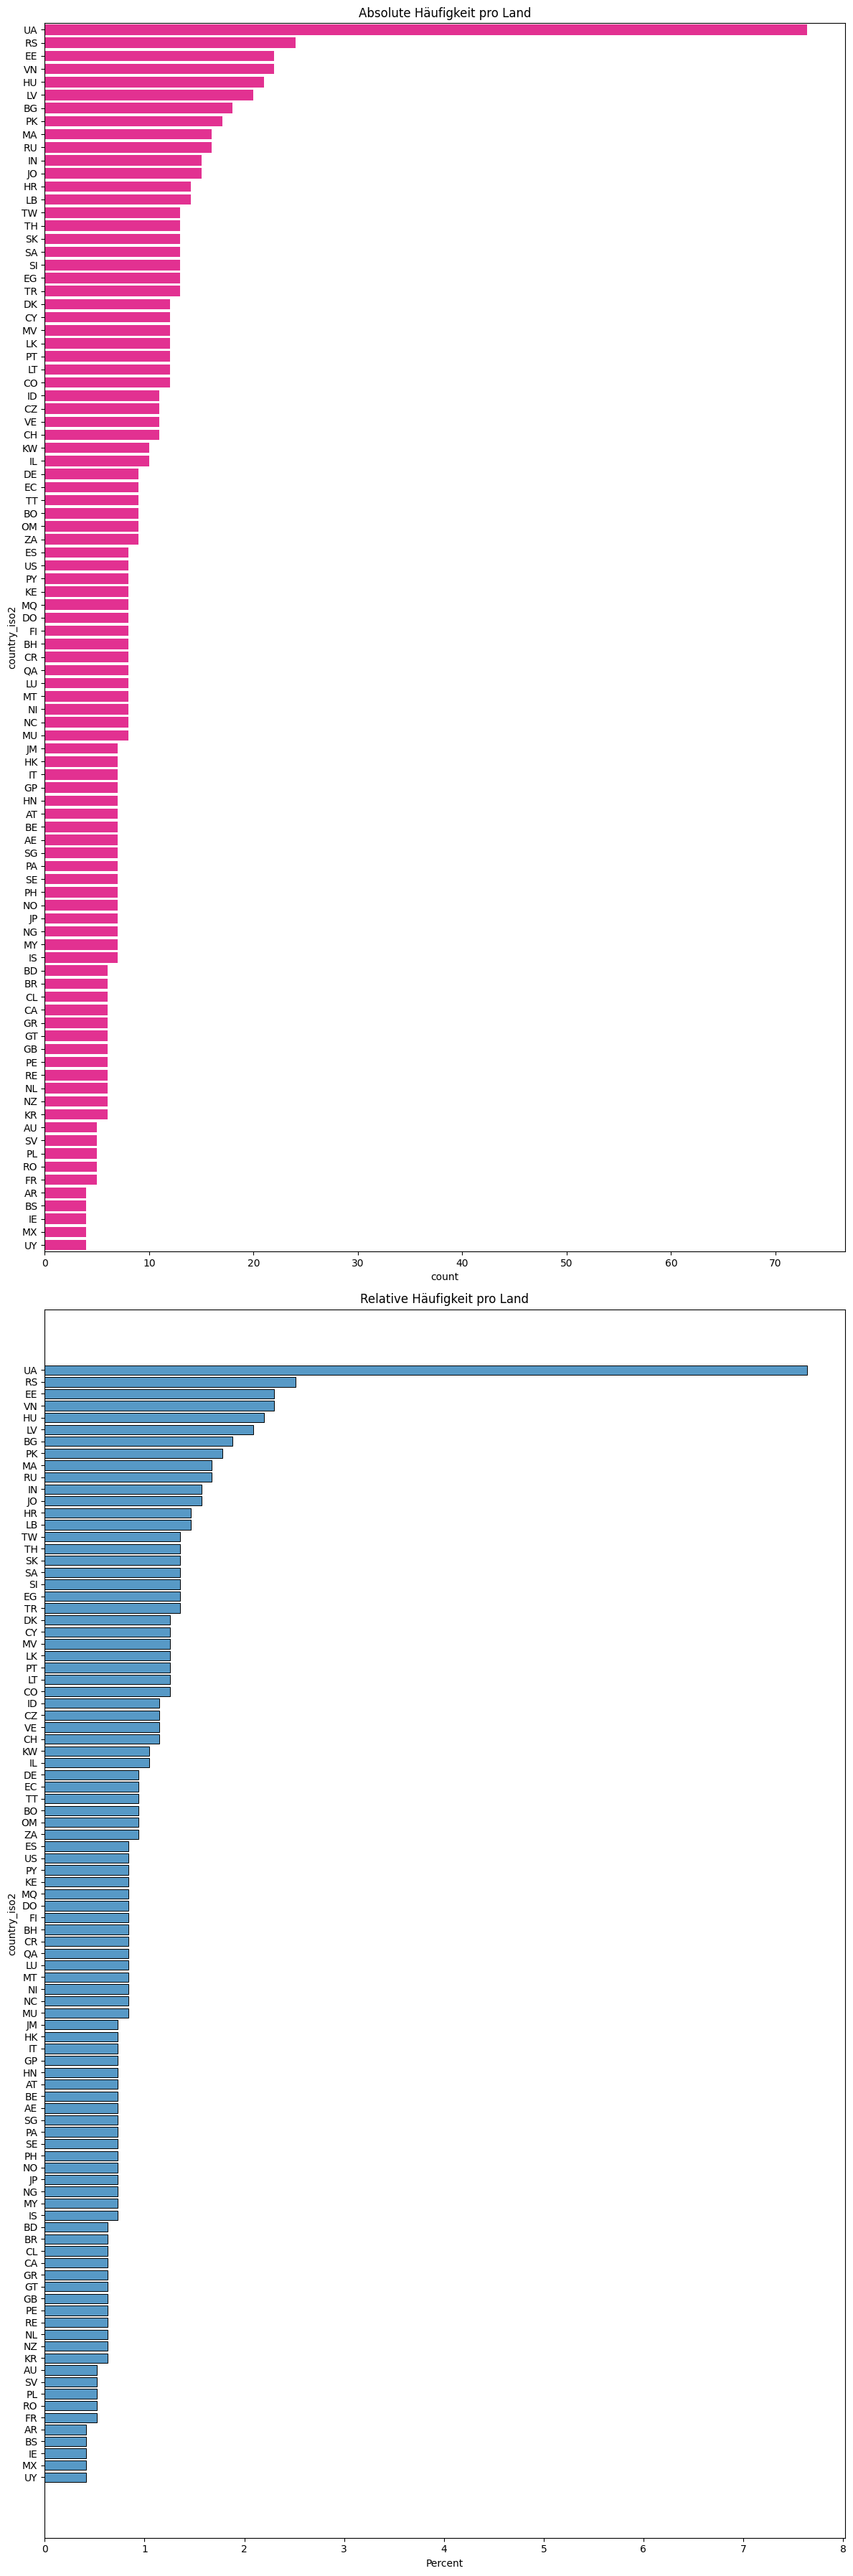

In [47]:
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(12, 36))

# Sortierte Reihenfolge
order = netflix_RedNotice['country_iso2'].value_counts().index

# Absolute Häufigkeit
sea.countplot(
    data=netflix_RedNotice,
    y='country_iso2',
    order=order,
    ax=axs[0],
    color='deeppink'
)

# Relative Häufigkeit
# histplot akzeptiert "y" als Kategorie, wir müssen vorher sortieren
netflix_sorted = netflix_RedNotice.copy()
netflix_sorted['country_iso2'] = pd.Categorical(netflix_sorted['country_iso2'], categories=order, ordered=True)

sea.histplot(
    data=netflix_sorted,
    y='country_iso2',
    stat='percent',
    ax=axs[1],
    shrink=0.8,
    discrete=True
)

axs[0].set_title('Absolute Häufigkeit pro Land')
axs[1].set_title('Relative Häufigkeit pro Land')

plt.tight_layout()
plt.show()

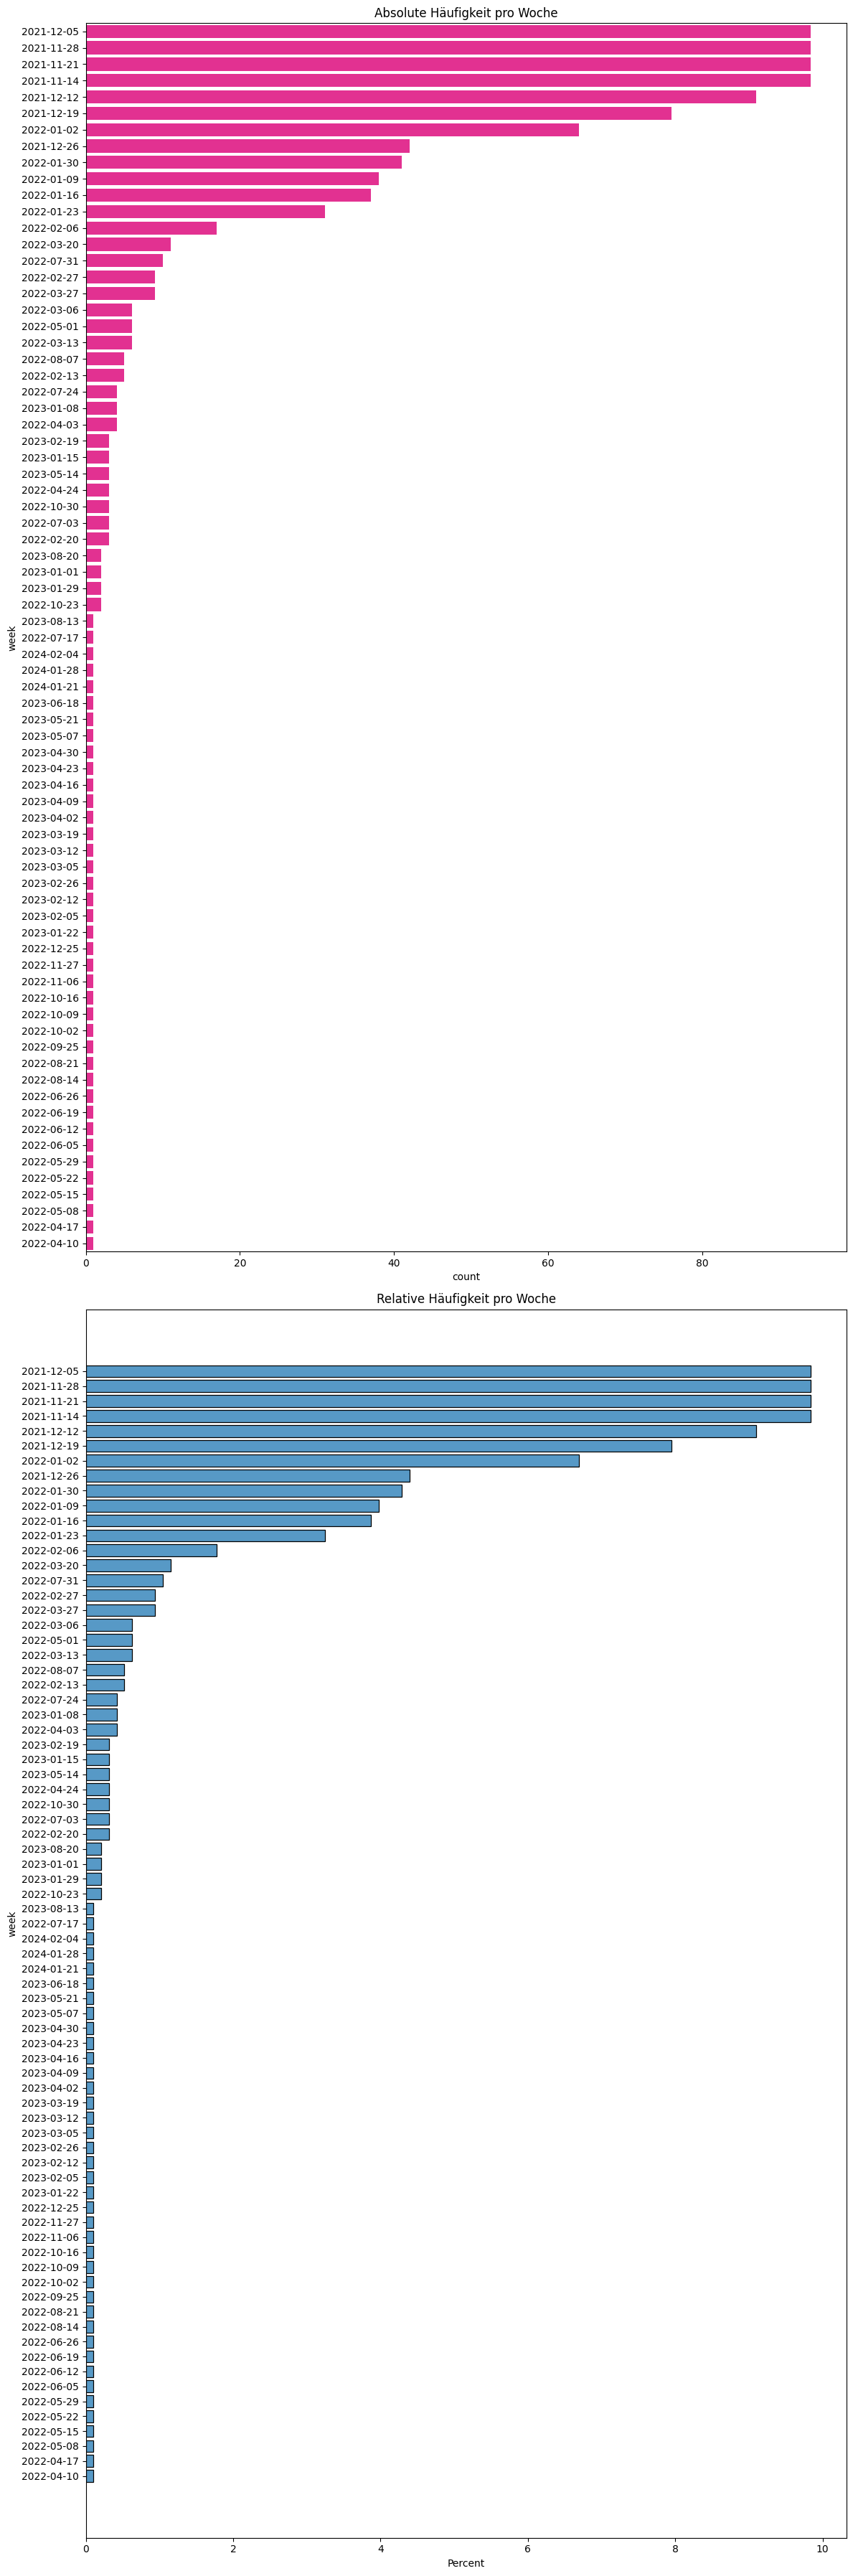

In [48]:
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(12, 36))

# Sortierte Reihenfolge
order = netflix_RedNotice['week'].value_counts().index

# Absolute Häufigkeit
sea.countplot(
    data=netflix_RedNotice,
    y='week',
    order=order,
    ax=axs[0],
    color='deeppink'
)

# Relative Häufigkeit
# histplot akzeptiert "y" als Kategorie, wir müssen vorher sortieren
netflix_sorted = netflix_RedNotice.copy()
netflix_sorted['week'] = pd.Categorical(netflix_sorted['week'], categories=order, ordered=True)

sea.histplot(
    data=netflix_sorted,
    y='week',
    stat='percent',
    ax=axs[1],
    shrink=0.8,
    discrete=True
)

axs[0].set_title('Absolute Häufigkeit pro Woche')
axs[1].set_title('Relative Häufigkeit pro Woche')

plt.tight_layout()
plt.show()

### Quantitative Daten

In [17]:
# einlesen des Datensatzes
netflix2 = pd.read_excel('all-weeks-global.xlsx')

## Frage

Benutze den Datensatz netflix2, um die relative und die kumulierte Häufigkeit für das Merkmal *runtime* darzustellen. 